In [2]:
#import libraries
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import time
import warnings
warnings.filterwarnings('ignore')


# Set a fixed random seed to ensure the results are reproducible
np.random.seed(42)
tf.random.set_seed(42)

2026-05-07 14:46:14.327474: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
print("loading Sign Language MNIST dataset...")

train_path = 'sign_mnist_train.csv'
test_path = 'sign_mnist_test.csv'

#load test_dataset
test_df = pd.read_csv(test_path) if os.path.exists(test_path) else None
if test_df is not None:
    print(f"load successfully！test_dataset shape: {test_df.shape}")
else:
    print(f"warm：didn't find the file {test_path}")

#load train_dataset
train_df = pd.read_csv(train_path) if os.path.exists(train_path) else None
if train_df is not None:
    print(f"load successfully！train_dataset shape: {train_df.shape}")
else:
    print(f"warm：didn't find the file {train_path}")

loading Sign Language MNIST dataset...
load successfully！test_dataset shape: (7172, 785)
load successfully！train_dataset shape: (27455, 785)


In [4]:
# label mapping（based on data announcement，exclude J and Z）
known_labels = list(range(9)) + list(range(10, 25))  # 0-8,10-24
label_map = {old: new for new, old in enumerate(known_labels)}
reverse_label_map = {new: old for old, new in label_map.items()}
num_classes = 24

def preprocess(df, label_map):
#extraction, mapping, normalisation、reshape
    y = df['label'].map(label_map).values
    X = df.drop('label', axis=1).values.astype('float32') / 255.0
    X = X.reshape(-1, 28, 28, 1)
    y_cat = to_categorical(y, num_classes=num_classes)
    return X, y_cat, y

X_train_full, y_train_full_cat, y_train_full = preprocess(train_df, label_map)
# divide train_data and test_data （10% for validation）
X_train, X_val, y_train_cat, y_val_cat = train_test_split(
    X_train_full, y_train_full_cat, test_size=0.1, random_state=42, stratify=y_train_full
)
print(f"train_data: {X_train.shape[0]} smaple")
print(f"Validation: {X_val.shape[0]} smaple")

#preprocess test_data
X_test, y_test_cat, y_test = preprocess(test_df, label_map)
print(f"test_data: {X_test.shape[0]} smaple")

train_data: 24709 smaple
Validation: 2746 smaple
test_data: 7172 smaple


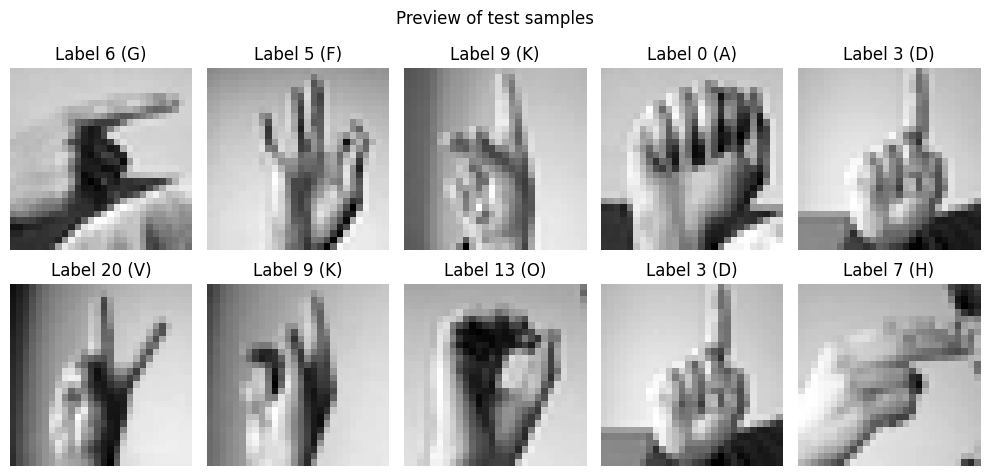

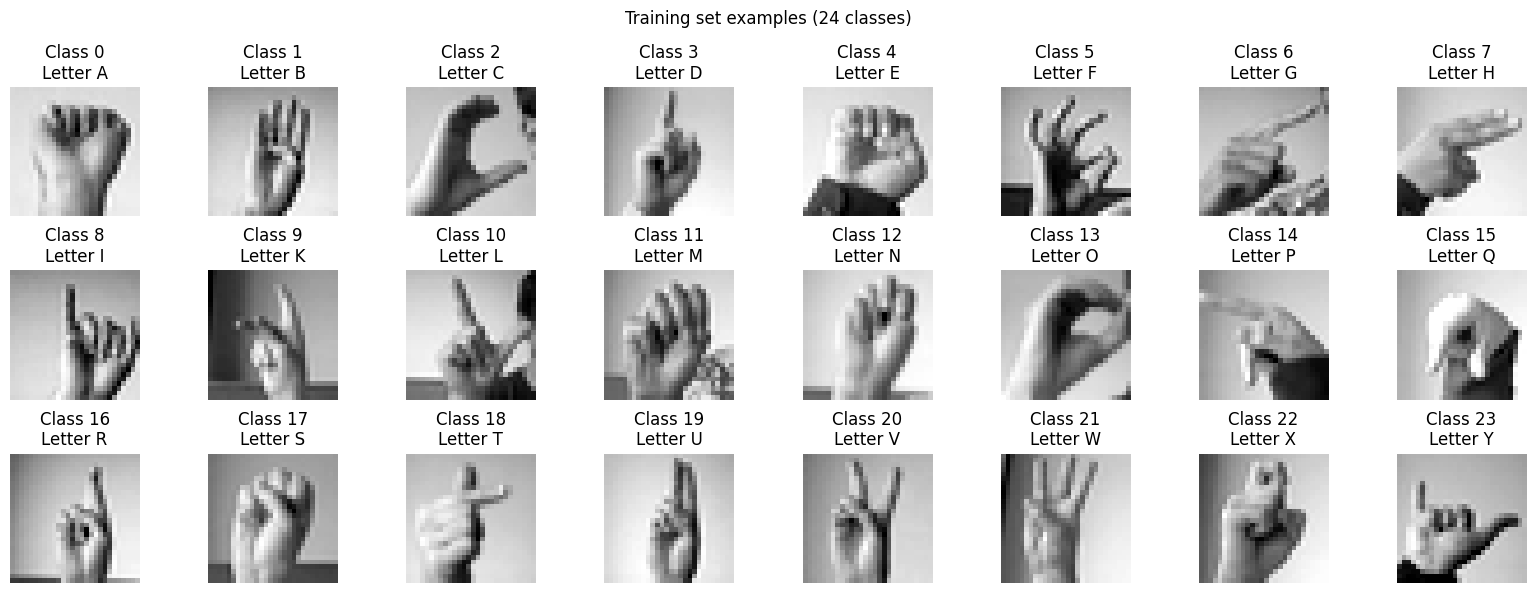

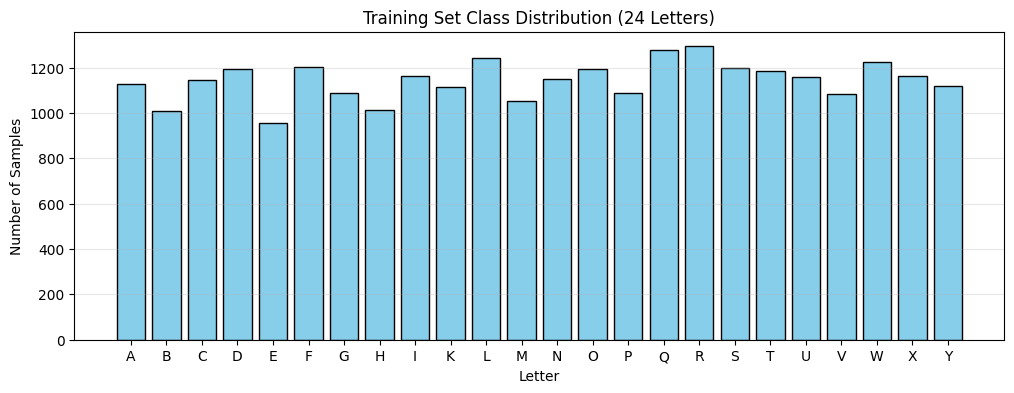

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    true_label = y_test[i]
    original_label = reverse_label_map[true_label]
    letter = chr(65 + original_label)
    axes[i].set_title(f"Label {true_label} ({letter})")
    axes[i].axis('off')
plt.suptitle("Preview of test samples")
plt.tight_layout()
plt.show()

# Display a sample of one type
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
axes = axes.flatten()
for i in range(24):
    idx = np.where(y_train_full == i)[0][0]
    axes[i].imshow(X_train_full[idx].reshape(28, 28), cmap='gray')
    letter = chr(65 + reverse_label_map[i])
    axes[i].set_title(f"Class {i}\nLetter {letter}")
    axes[i].axis('off')
plt.suptitle("Training set examples (24 classes)")
plt.tight_layout()
plt.show()

# Category distribution chart
plt.figure(figsize=(12, 4))
class_counts = pd.Series(y_train_full).value_counts().sort_index()
letters = [chr(65 + reverse_label_map[i]) for i in range(24)]
plt.bar(letters, class_counts.values, color='skyblue', edgecolor='black')
plt.title('Training Set Class Distribution (24 Letters)')
plt.xlabel('Letter')
plt.ylabel('Number of Samples')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [7]:
def build_simple_cnn(input_shape=(28, 28, 1), num_classes=24):

#Simple baseline CNN
#No BatchNorm and Dropout is used to prevent overfitting

    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_vgg_style_cnn(input_shape=(28, 28, 1), num_classes=24):

#Enhanced VGG-style CNN
#3 convolutional blocks, each with 2 convolutional layers，BatchNorm + Dropout

    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [8]:
def compile_and_train(model, model_name, X_train, y_train, X_val, y_val,
                      epochs=30, batch_size=64, lr=0.001, optimizer_name='adam'):
    #Compile and train the model, returning the training history and elapsed time
    #Select an optimiser
    if optimizer_name == 'adam':
        opt = optimizers.Adam(learning_rate=lr)
    elif optimizer_name == 'sgd':
        opt = optimizers.SGD(learning_rate=lr, momentum=0.9)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")
    
    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    #Callback functions: Learning rate decay and early stopping
    lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                   min_lr=1e-7, verbose=1)
    early_stop = EarlyStopping(monitor='val_accuracy', patience=10,
                               restore_best_weights=True, verbose=1)
    start_time = time.time()
    history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs,
                        validation_data=(X_val, y_val),
                        callbacks=[lr_reducer, early_stop], verbose=1)
    train_time = time.time() - start_time
    return history, train_time

In [9]:
def plot_training_history(history, model_name):
    #Plotting training/validation accuracy and loss curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, model_name, reverse_label_map):
    #Generate a confusion matrix heatmap’
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 12))
    labels = [chr(65 + reverse_label_map[i]) for i in range(24)]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def visualize_predictions(model, X_test, y_test_int, reverse_label_map, num_samples=16):
    #Randomly displays the prediction results for a number of test samples 
    #it means green for correct, red for incorrect
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    indices = np.random.choice(len(X_test), num_samples, replace=False)

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    for i, idx in enumerate(indices):
        img = X_test[idx].reshape(28, 28)
        true_l = y_test_int[idx]
        pred_l = y_pred_classes[idx]
        true_letter = chr(65 + reverse_label_map[true_l])
        pred_letter = chr(65 + reverse_label_map[pred_l])
        color = 'green' if true_l == pred_l else 'red'
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'True: {true_letter} | Pred: {pred_letter}', color=color)
        axes[i].axis('off')
    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)')
    plt.tight_layout()
    plt.show()

In [10]:
print("\n Hyperparameter grid search ")
    
search_results = []
lr_values = [0.001, 0.0005]
batch_sizes = [32, 64, 128]
optimizers_to_test = ['adam', 'sgd']
    
for lr in lr_values:
    for bs in batch_sizes:
        for opt_name in optimizers_to_test:
            print(f"test: lr={lr}, batch_size={bs}, optimizer={opt_name}")
            temp_model = build_simple_cnn()
            if opt_name == 'adam':
                opt = optimizers.Adam(learning_rate=lr)
            else:
                opt = optimizers.SGD(learning_rate=lr, momentum=0.9)
                
            temp_model.compile(optimizer=opt,
                                loss='categorical_crossentropy',
                                metrics=['accuracy'])
            # early stop
            hist = temp_model.fit(X_train, y_train_cat,
                                   batch_size=bs,
                                   epochs=8,
                                   validation_data=(X_val, y_val_cat),
                                   verbose=0,
                                   callbacks=[EarlyStopping(monitor='val_accuracy',
                                                             patience=3,
                                                             restore_best_weights=True,
                                                             verbose=0)])
            best_val_acc = max(hist.history['val_accuracy'])
            final_train_acc = hist.history['accuracy'][-1]
            search_results.append({
                'lr': lr,
                'batch_size': bs,
                'optimizer': opt_name,
                'val_acc': best_val_acc,
                'train_acc': final_train_acc
            })
            print(f"  -> Val Acc: {best_val_acc:.4f}, Train Acc: {final_train_acc:.4f}")
    
# Identify the best parameters
best_result = max(search_results, key=lambda x: x['val_acc'])
BEST_LR = best_result['lr']
BEST_BATCH = best_result['batch_size']
BEST_OPTIMIZER = best_result['optimizer']
    
print("\nthe best combination of parameters:")
    print(f"  Learning rate: {BEST_LR}, Batch size: {BEST_BATCH}, Optimizer: {BEST_OPTIMIZER}")
    print(f"  Verification accuracy: {best_result['val_acc']:.4f}")


 Hyperparameter grid search 
test: lr=0.001, batch_size=32, optimizer=adam
  -> Val Acc: 1.0000, Train Acc: 0.9648
test: lr=0.001, batch_size=32, optimizer=sgd
  -> Val Acc: 0.9403, Train Acc: 0.7916
test: lr=0.001, batch_size=64, optimizer=adam
  -> Val Acc: 1.0000, Train Acc: 0.9668
test: lr=0.001, batch_size=64, optimizer=sgd
  -> Val Acc: 0.6650, Train Acc: 0.4634
test: lr=0.001, batch_size=128, optimizer=adam
  -> Val Acc: 1.0000, Train Acc: 0.9427
test: lr=0.001, batch_size=128, optimizer=sgd
  -> Val Acc: 0.4377, Train Acc: 0.2994
test: lr=0.0005, batch_size=32, optimizer=adam
  -> Val Acc: 1.0000, Train Acc: 0.9679
test: lr=0.0005, batch_size=32, optimizer=sgd
  -> Val Acc: 0.7236, Train Acc: 0.5435
test: lr=0.0005, batch_size=64, optimizer=adam
  -> Val Acc: 1.0000, Train Acc: 0.9252
test: lr=0.0005, batch_size=64, optimizer=sgd
  -> Val Acc: 0.4829, Train Acc: 0.3216
test: lr=0.0005, batch_size=128, optimizer=adam
  -> Val Acc: 0.9989, Train Acc: 0.9286
test: lr=0.0005, batc


train Simple CNN
Epoch 1/30
773/773 [==============================] - 7s 8ms/step - loss: 1.6301 - accuracy: 0.4831 - val_loss: 0.3484 - val_accuracy: 0.9115 - lr: 0.0010
Epoch 2/30
773/773 [==============================] - 7s 9ms/step - loss: 0.5714 - accuracy: 0.7975 - val_loss: 0.1207 - val_accuracy: 0.9847 - lr: 0.0010
Epoch 3/30
773/773 [==============================] - 7s 9ms/step - loss: 0.3738 - accuracy: 0.8642 - val_loss: 0.0481 - val_accuracy: 0.9942 - lr: 0.0010
Epoch 4/30
773/773 [==============================] - 7s 9ms/step - loss: 0.2752 - accuracy: 0.8999 - val_loss: 0.0245 - val_accuracy: 0.9967 - lr: 0.0010
Epoch 5/30
773/773 [==============================] - 7s 9ms/step - loss: 0.2244 - accuracy: 0.9203 - val_loss: 0.0077 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 6/30
773/773 [==============================] - 7s 8ms/step - loss: 0.1867 - accuracy: 0.9309 - val_loss: 0.0045 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 7/30
773/773 [==============================] 

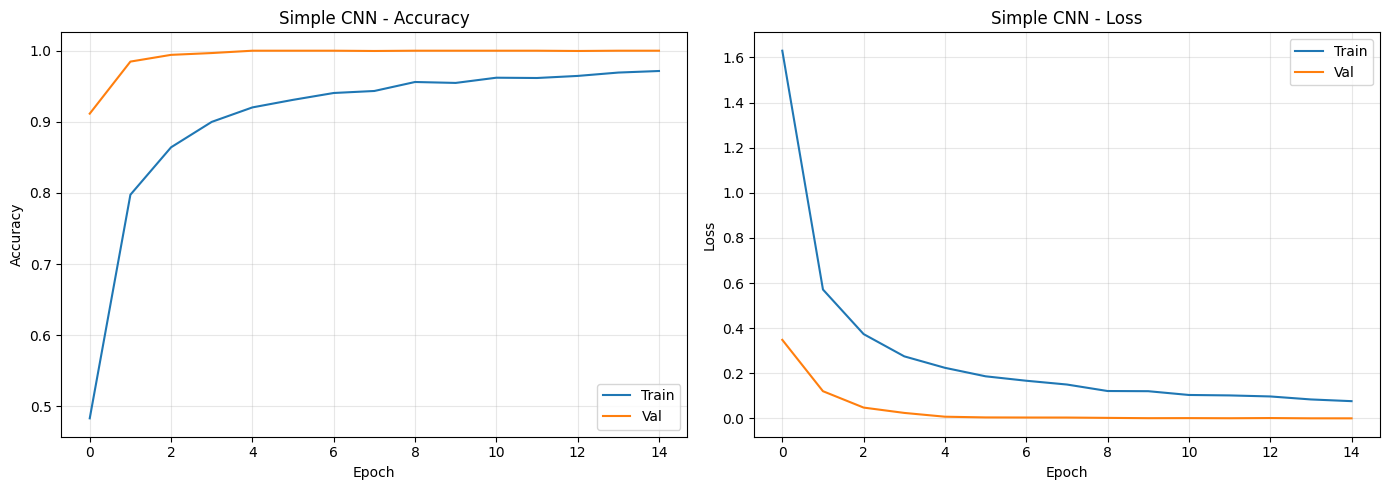


train VGG-Style CNN ...
Epoch 1/30
773/773 [==============================] - 31s 39ms/step - loss: 1.3606 - accuracy: 0.5966 - val_loss: 0.1193 - val_accuracy: 0.9745 - lr: 0.0010
Epoch 2/30
773/773 [==============================] - 31s 39ms/step - loss: 0.2189 - accuracy: 0.9354 - val_loss: 0.0099 - val_accuracy: 0.9978 - lr: 0.0010
Epoch 3/30
773/773 [==============================] - 30s 39ms/step - loss: 0.0799 - accuracy: 0.9771 - val_loss: 0.0071 - val_accuracy: 0.9993 - lr: 0.0010
Epoch 4/30
773/773 [==============================] - 30s 39ms/step - loss: 0.0469 - accuracy: 0.9864 - val_loss: 0.0022 - val_accuracy: 0.9996 - lr: 0.0010
Epoch 5/30
773/773 [==============================] - 31s 40ms/step - loss: 0.0463 - accuracy: 0.9858 - val_loss: 0.0097 - val_accuracy: 0.9971 - lr: 0.0010
Epoch 6/30
773/773 [==============================] - 31s 40ms/step - loss: 0.0365 - accuracy: 0.9893 - val_loss: 0.0015 - val_accuracy: 0.9996 - lr: 0.0010
Epoch 7/30
773/773 [=============

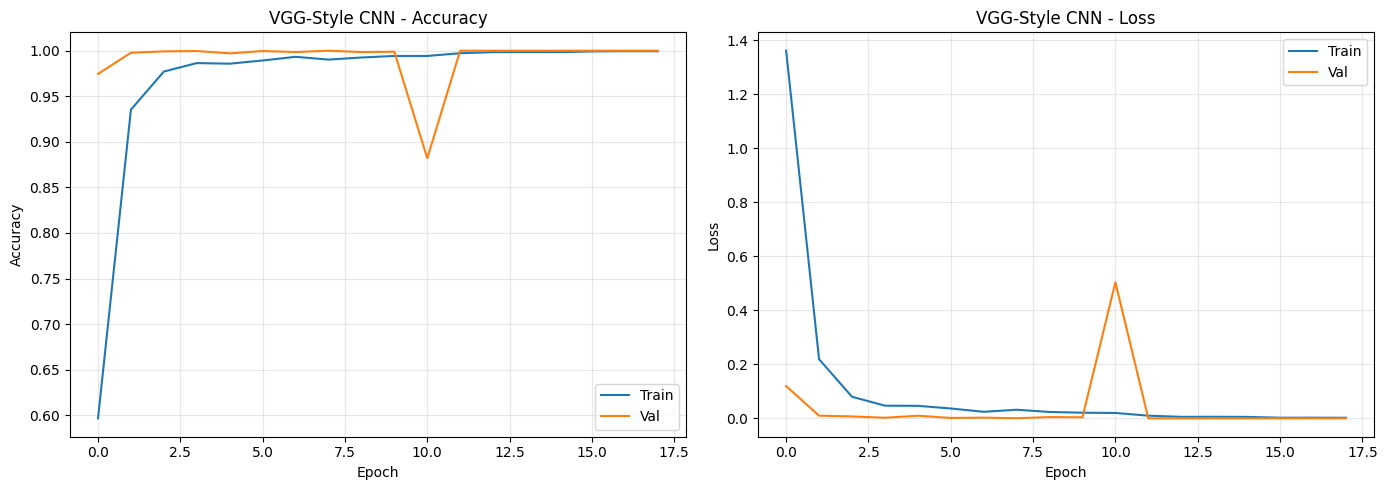


------------------------------------------------------------
Comparison of Model Performance
------------------------------------------------------------
model              Test accuracy Test loss  Number of arguments Training times(second)
------------------------------------------------------------
Simple CNN         0.9380     0.2480     423,448      100.8       
VGG-Style CNN      0.9893     0.0229     620,920      553.0       

the best model: VGG-Style CNN (accuracy 0.9893)


In [11]:
# if train_df is not None:
results = {}
    
#simple CNN
simple_model = build_simple_cnn()
print("\ntrain Simple CNN")
hist_simple, time_simple = compile_and_train(simple_model, "Simple CNN",
                                             X_train, y_train_cat, X_val, y_val_cat,
                                             epochs=30, batch_size=BEST_BATCH, lr=BEST_LR,
                                             optimizer_name=BEST_OPTIMIZER)
plot_training_history(hist_simple, "Simple CNN")
test_loss_simple, test_acc_simple = simple_model.evaluate(X_test, y_test_cat, verbose=0)
results['Simple CNN'] = {'history': hist_simple, 'test_acc': test_acc_simple,
                         'test_loss': test_loss_simple, 'time': time_simple,
                         'model': simple_model}
    
#VGG-style CN
vgg_model = build_vgg_style_cnn()
print("\ntrain VGG-Style CNN ...")
hist_vgg, time_vgg = compile_and_train(vgg_model, "VGG-Style CNN",
                                       X_train, y_train_cat, X_val, y_val_cat,
                                       epochs=30, batch_size=BEST_BATCH, lr=BEST_LR,
                                       optimizer_name=BEST_OPTIMIZER)
plot_training_history(hist_vgg, "VGG-Style CNN")
test_loss_vgg, test_acc_vgg = vgg_model.evaluate(X_test, y_test_cat, verbose=0)
results['VGG-Style CNN'] = {'history': hist_vgg, 'test_acc': test_acc_vgg,
                            'test_loss': test_loss_vgg, 'time': time_vgg,
                            'model': vgg_model}
    
# Comparison table
print("\n" + "-"*60)
print("Comparison of Model Performance")
print("-"*60)
print(f"{'model':<18} {'Test accuracy':<10} {'Test loss':<10} {'Number of arguments':<12} {'Training times(second)':<12}")
print("-"*60)
for name, res in results.items():
    params = res['model'].count_params()
    print(f"{name:<18} {res['test_acc']:<10.4f} {res['test_loss']:<10.4f} {params:<12,} {res['time']:<12.1f}")
    
best_name = max(results, key=lambda x: results[x]['test_acc'])
best_model = results[best_name]['model']
print(f"\nthe best model: {best_name} (accuracy {results[best_name]['test_acc']:.4f})")

Evaluate the best model in detail: VGG-Style CNN


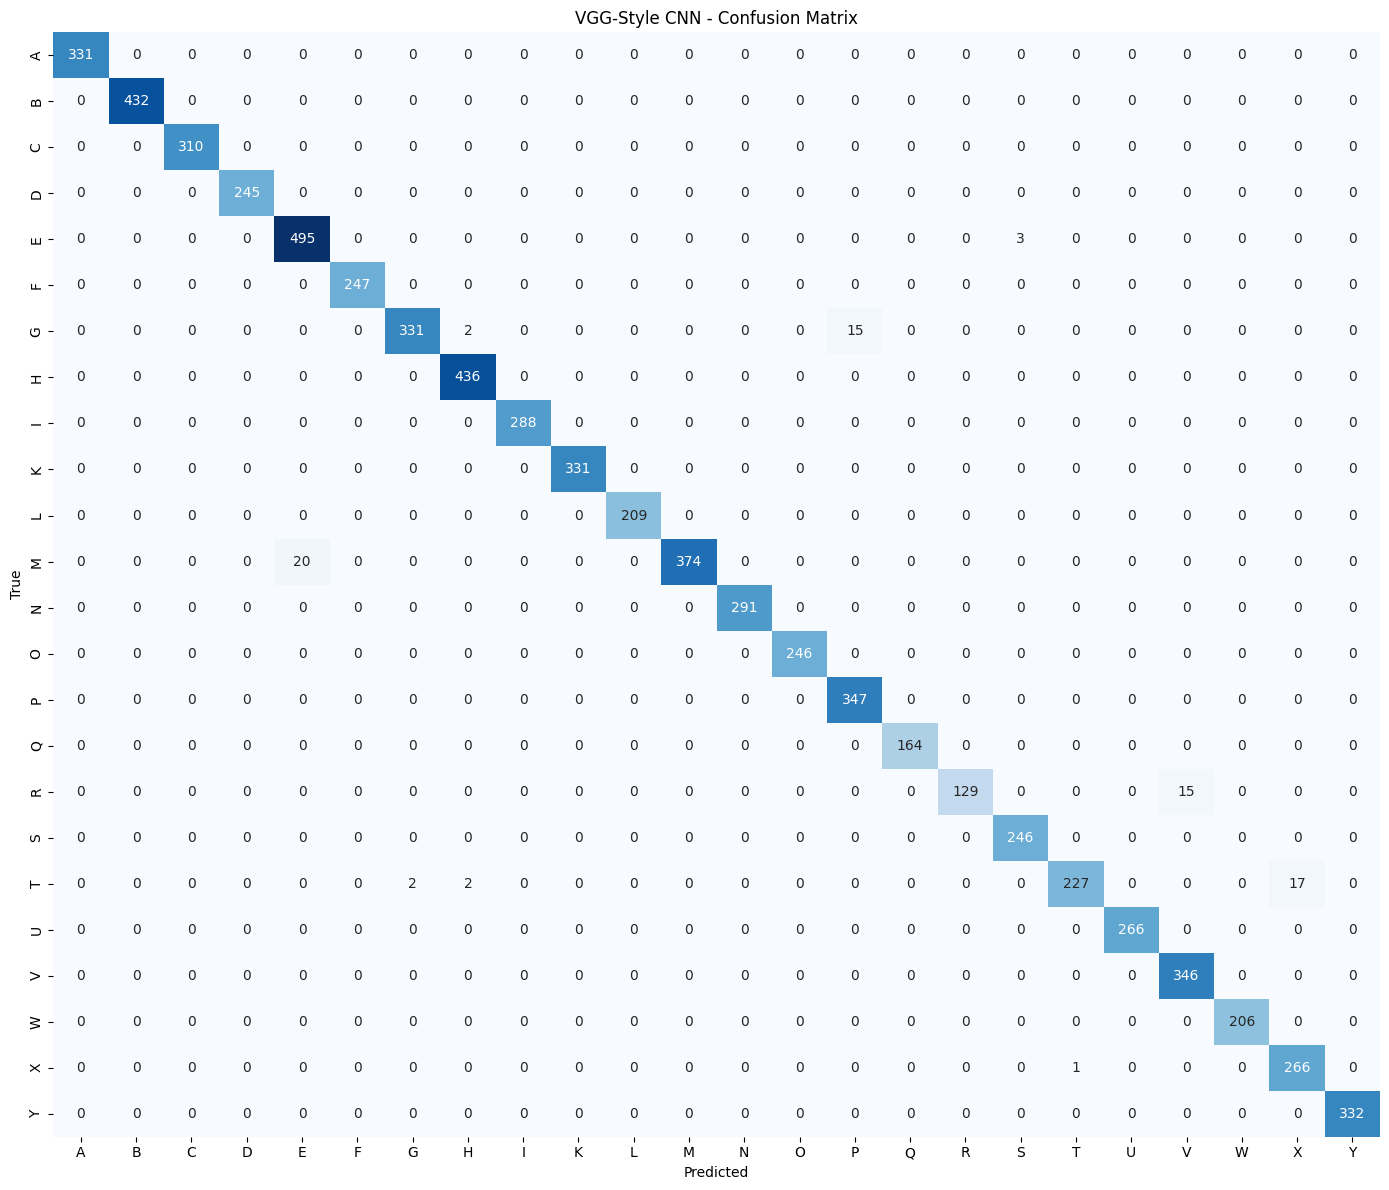


Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       0.96      0.99      0.98       498
           F       1.00      1.00      1.00       247
           G       0.99      0.95      0.97       348
           H       0.99      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       1.00      1.00      1.00       209
           M       1.00      0.95      0.97       394
           N       1.00      1.00      1.00       291
           O       1.00      1.00      1.00       246
           P       0.96      1.00      0.98       347
           Q       1.00      1.00      1.00       164
           R       1.00      0.90      0.95       144
   

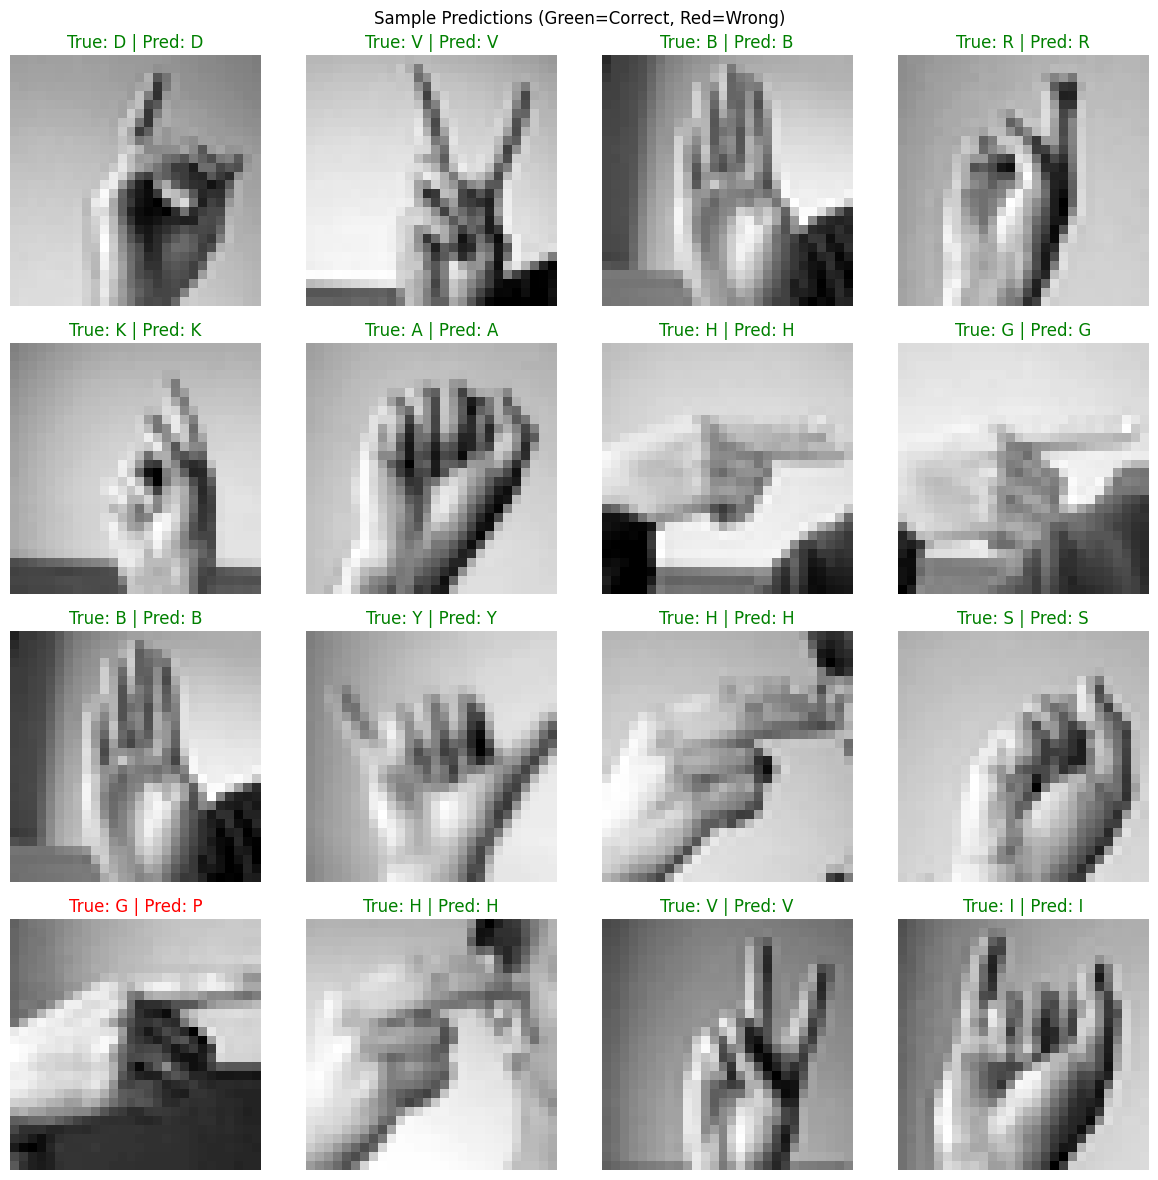

In [14]:
print(f"Evaluate the best model in detail: {best_name}")
    
y_pred = best_model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
    
plot_confusion_matrix(y_test, y_pred_classes, best_name, reverse_label_map)
    
target_names = [chr(65 + reverse_label_map[i]) for i in range(24)]
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=target_names))
    
visualize_predictions(best_model, X_test, y_test, reverse_label_map)